# Introduction

Since Jan. 1, 2015, [The Washington Post](https://www.washingtonpost.com/) has been compiling a database of every fatal shooting in the US by a police officer in the line of duty. 

<center><img src=https://i.imgur.com/sX3K62b.png></center>

While there are many challenges regarding data collection and reporting, The Washington Post has been tracking more than a dozen details about each killing. This includes the race, age and gender of the deceased, whether the person was armed, and whether the victim was experiencing a mental-health crisis. The Washington Post has gathered this supplemental information from law enforcement websites, local new reports, social media, and by monitoring independent databases such as "Killed by police" and "Fatal Encounters". The Post has also conducted additional reporting in many cases.

There are 4 additional datasets: US census data on poverty rate, high school graduation rate, median household income, and racial demographics. [Source of census data](https://factfinder.census.gov/faces/nav/jsf/pages/community_facts.xhtml).

### Upgrade Plotly

Run the cell below if you are working with Google Colab

In [1]:
from debugpy.common.util import hide_debugpy_internals

from day_018.project.spot_painting.main import color
%pip install --upgrade plotly


[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Import Statements

In [2]:
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

# This might be helpful:
from collections import Counter

## Notebook Presentation

In [3]:
pd.options.display.float_format = '{:,.2f}'.format

## Load the Data

In [4]:
df_hh_income = pd.read_csv('Median_Household_Income_2015.csv', encoding="windows-1252")
df_pct_poverty = pd.read_csv('Pct_People_Below_Poverty_Level.csv', encoding="windows-1252")
df_pct_completed_hs = pd.read_csv('Pct_Over_25_Completed_High_School.csv', encoding="windows-1252")
df_share_race_city = pd.read_csv('Share_of_Race_By_City.csv', encoding="windows-1252")
df_fatalities = pd.read_csv('Deaths_by_Police_US.csv', encoding="windows-1252")

# Preliminary Data Exploration

* What is the shape of the DataFrames? 
* How many rows and columns do they have?
* What are the column names?
* Are there any NaN values or duplicates?

In [6]:
df_hh_income.shape

(29322, 3)

In [7]:
df_pct_poverty.shape

(29329, 3)

In [8]:
df_pct_completed_hs.shape

(29329, 3)

In [9]:
df_share_race_city.shape

(29268, 7)

In [5]:
df_fatalities.shape

(2535, 14)

## Data Cleaning - Check for Missing Values and Duplicates

Consider how to deal with the NaN values. Perhaps substituting 0 is appropriate.

In [14]:
df_hh_income = df_hh_income.dropna()
df_hh_income.isna().values.any()

np.True_

In [27]:
df_pct_poverty.isna().values.any()
df_pct_poverty.dropna()

np.False_

In [17]:
df_fatalities.isna().values.any()

np.True_

In [15]:
df_share_race_city.isna().values.any()

np.False_

In [16]:
df_pct_completed_hs.isna().values.any()

np.False_

In [18]:
df_pct_poverty.isna().values.any()

np.False_

# Chart the Poverty Rate in each US State

Create a bar chart that ranks the poverty rate from highest to lowest by US state. Which state has the highest poverty rate? Which state has the lowest poverty rate?  Bar Plot

In [28]:
df_pct_poverty.head()

,Geographic Area,City,poverty_rate
0,AL,Abanda CDP,78.8
1,AL,Abbeville city,29.1
2,AL,Adamsville city,25.5
3,AL,Addison town,30.7
4,AL,Akron town,42


In [39]:
df_pct_poverty["poverty_rate"] = pd.to_numeric(df_pct_poverty["poverty_rate"], errors='coerce')

In [43]:
highest_to_lowest_poverty_by_state = (
    df_pct_poverty
    .groupby("Geographic Area")["poverty_rate"]
    .mean()
    .sort_values(ascending=False)
)

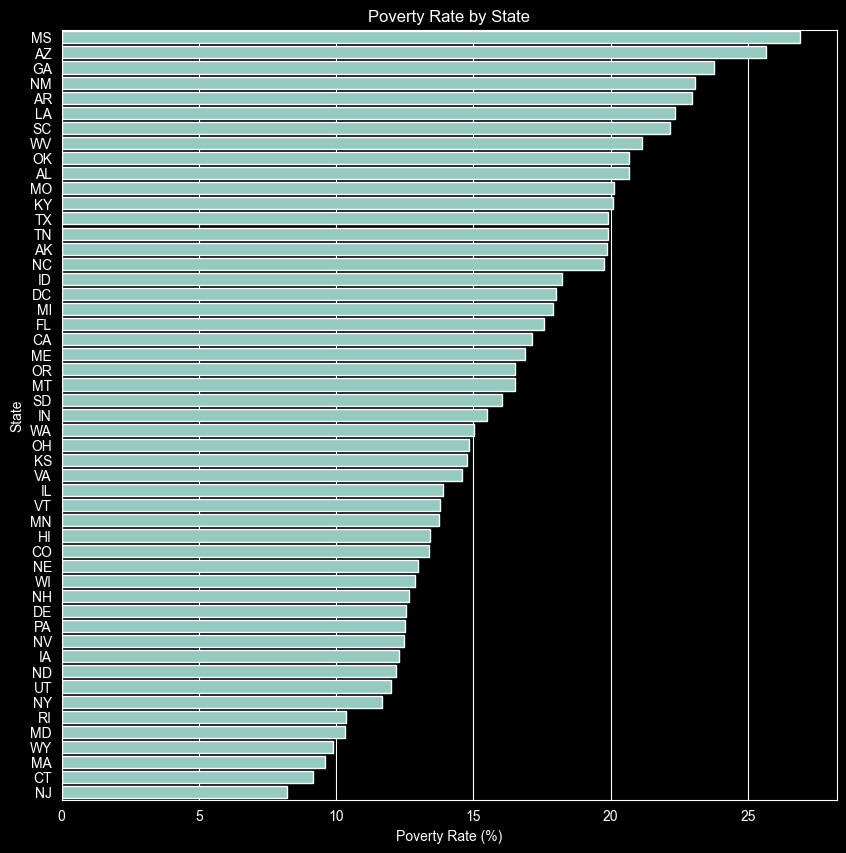

In [45]:
plt.figure(figsize=(10, 10))
sns.barplot(
    x=highest_to_lowest_poverty_by_state.values,
    y=highest_to_lowest_poverty_by_state.index,
)

plt.title("Poverty Rate by State")

plt.xlabel("Poverty Rate (%)")
plt.ylabel("State")
plt.show()

# Chart the High School Graduation Rate by US State

Show the High School Graduation Rate in ascending order of US States. Which state has the lowest high school graduation rate? Which state has the highest?

In [46]:
df_pct_completed_hs.head

<bound method NDFrame.head of       Geographic Area                    City percent_completed_hs
0                  AL              Abanda CDP                 21.2
1                  AL          Abbeville city                 69.1
2                  AL         Adamsville city                 78.9
3                  AL            Addison town                 81.4
4                  AL              Akron town                 68.6
...               ...                     ...                  ...
29324              WY  Woods Landing-Jelm CDP                  100
29325              WY            Worland city                 85.6
29326              WY             Wright town                 89.2
29327              WY              Yoder town                 79.4
29328              WY           Y-O Ranch CDP                  100

[29329 rows x 3 columns]>

In [47]:
df_pct_completed_hs["percent_completed_hs"] = pd.to_numeric(df_pct_completed_hs["percent_completed_hs"], errors='coerce')

In [48]:
graduation_by_state = (df_pct_completed_hs.groupby("Geographic Area")["percent_completed_hs"].mean().sort_values(ascending=False))

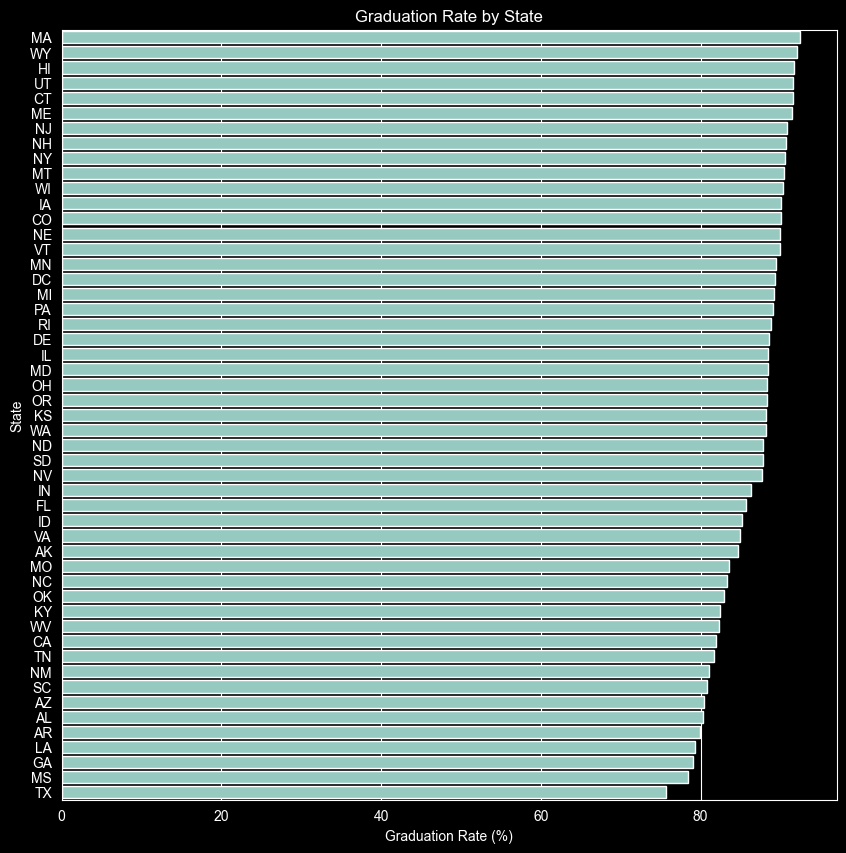

In [52]:
plt.figure(figsize=(10, 10))
sns.barplot(
    x=graduation_by_state.values,
    y=graduation_by_state.index,
)

plt.title("Graduation Rate by State")

plt.xlabel("Graduation Rate (%)")
plt.ylabel("State")
plt.show()

# Visualise the Relationship between Poverty Rates and High School Graduation Rates

#### Create a line chart with two y-axes to show if the rations of poverty and high school graduation move together.

In [54]:
df_pct_completed_hs.head()

,Geographic Area,City,percent_completed_hs
0,AL,Abanda CDP,21.20
1,AL,Abbeville city,69.10
2,AL,Adamsville city,78.90
3,AL,Addison town,81.40
4,AL,Akron town,68.60


In [55]:
poverty_by_state = (
    df_pct_poverty
    .groupby("Geographic Area")["poverty_rate"]
    .mean()
    .sort_index()
)

hs_by_state = (
    df_pct_completed_hs
    .groupby("Geographic Area")["percent_completed_hs"]
    .mean()
    .sort_index()
)

In [56]:
poverty_hs_df = pd.DataFrame({"poverty_rate": poverty_by_state, "percent_completed_hs": hs_by_state})

poverty_hs_df.head()

,poverty_rate,percent_completed_hs
Geographic Area,,
AK,19.85,84.63
AL,20.65,80.30
AR,22.96,79.95
AZ,25.67,80.47
CA,17.12,81.96


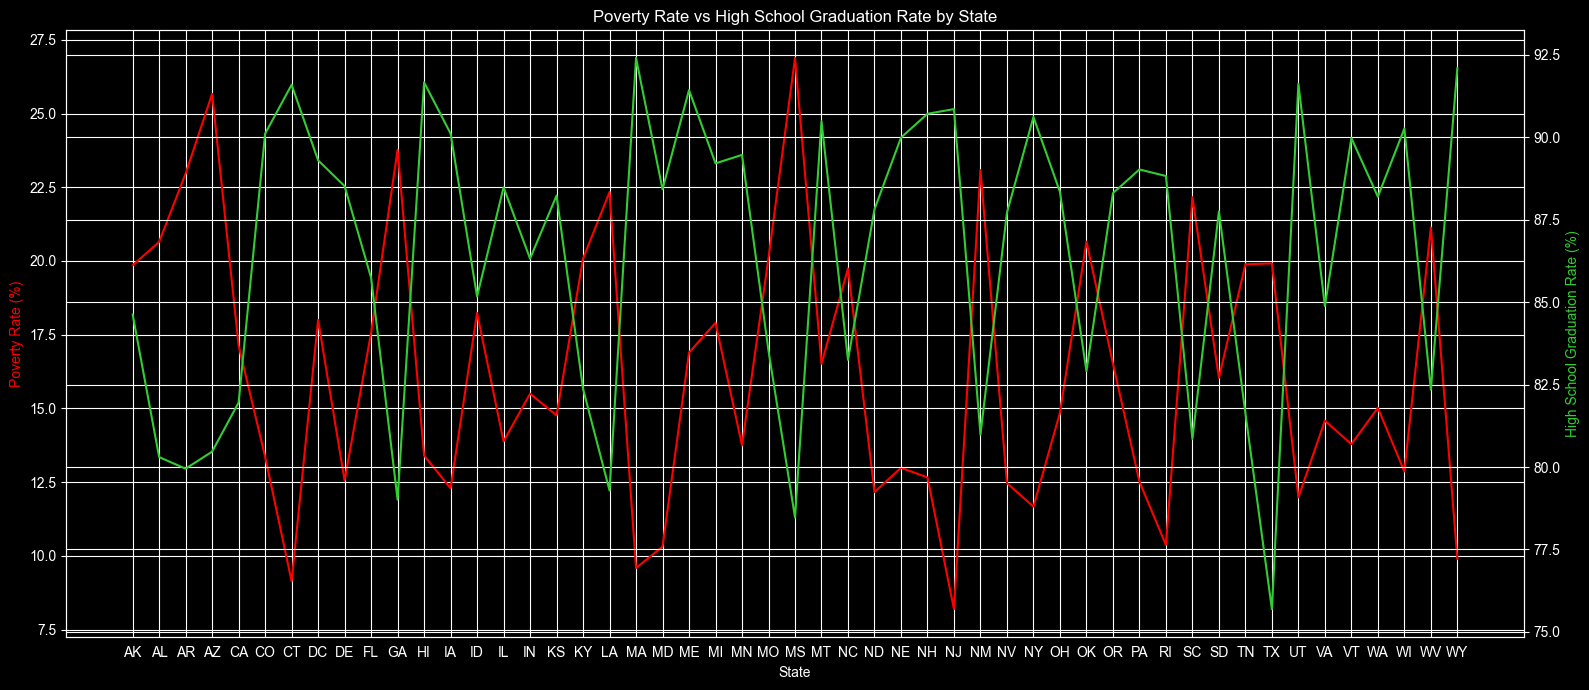

In [59]:
fig, ax1 = plt.subplots(figsize=(16, 7))

ax1.plot(
    poverty_hs_df.index,
    poverty_hs_df["poverty_rate"],
    label="Poverty Rate",
    color="red"
)

ax1.set_xlabel("State")
ax1.set_ylabel("Poverty Rate (%)", color="red")


ax2 = ax1.twinx()

ax2.plot(
    poverty_hs_df.index,
    poverty_hs_df["percent_completed_hs"],
    label="High School Graduation Rate",
      color="limegreen"
)

ax2.set_ylabel("High School Graduation Rate (%)", color="limegreen")

plt.title("Poverty Rate vs High School Graduation Rate by State")

fig.tight_layout()
plt.show()

#### Now use a Seaborn .jointplot() with a Kernel Density Estimate (KDE) and/or scatter plot to visualise the same relationship

In [62]:
poverty_by_state = (
    df_pct_poverty
    .groupby("Geographic Area")["poverty_rate"]
    .mean()
)

hs_by_state = (
    df_pct_completed_hs
    .groupby("Geographic Area")["percent_completed_hs"]
    .mean()
)

relationship_df = pd.DataFrame({
    "poverty_rate": poverty_by_state,
    "graduation_rate": hs_by_state
}).dropna()

relationship_df.head()

,poverty_rate,graduation_rate
Geographic Area,,
AK,19.85,84.63
AL,20.65,80.30
AR,22.96,79.95
AZ,25.67,80.47
CA,17.12,81.96


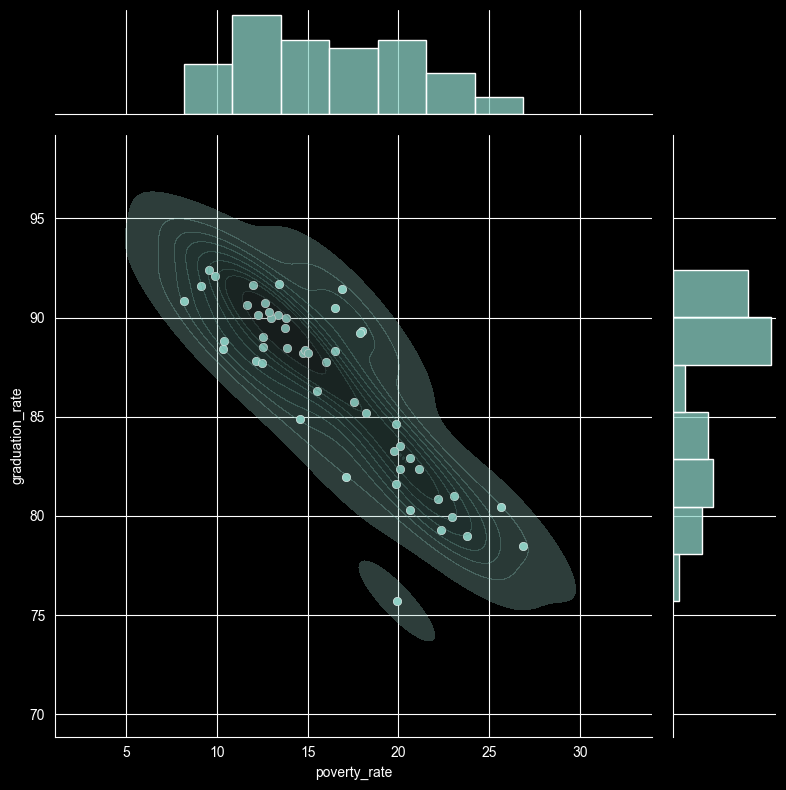

In [67]:
sns.jointplot(
    data=relationship_df,
    x="poverty_rate",
    y="graduation_rate",
    kind="scatter",
    height=8
)

sns.kdeplot(
    data=relationship_df,
    x="poverty_rate",
    y="graduation_rate",
    fill=True,
    alpha=0.3
)

plt.show()

#### Seaborn's `.lmplot()` or `.regplot()` to show a linear regression between the poverty ratio and the high school graduation ratio. 

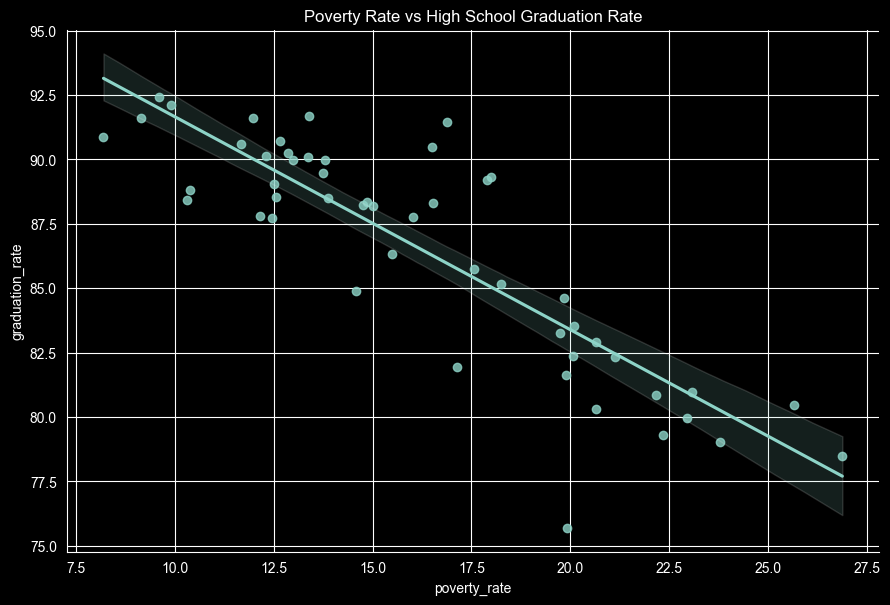

In [68]:
sns.lmplot(
    data=relationship_df,
    x="poverty_rate",
    y="graduation_rate",
    height=6,
    aspect=1.5
)

plt.title("Poverty Rate vs High School Graduation Rate")

plt.show()

# Create a Bar Chart with Subsections Showing the Racial Makeup of Each US State

Visualise the share of the white, black, hispanic, asian and native american population in each US State using a bar chart with sub sections.

In [70]:
df_share_race_city.head()


,Geographic area,City,share_white,share_black,share_native_american,share_asian,share_hispanic
0,AL,Abanda CDP,67.2,30.2,0,0,1.6
1,AL,Abbeville city,54.4,41.4,0.1,1,3.1
2,AL,Adamsville city,52.3,44.9,0.5,0.3,2.3
3,AL,Addison town,99.1,0.1,0,0.1,0.4
4,AL,Akron town,13.2,86.5,0,0,0.3


In [75]:
df_share_race_city["share_white"] = pd.to_numeric(df_share_race_city["share_white"], errors='coerce')
df_share_race_city["share_black"] = pd.to_numeric(df_share_race_city["share_black"], errors='coerce')
df_share_race_city["share_native_american"] = pd.to_numeric(df_share_race_city["share_native_american"], errors='coerce')
df_share_race_city["share_asian"] = pd.to_numeric(df_share_race_city["share_asian"], errors='coerce')
df_share_race_city["share_hispanic"] = pd.to_numeric(df_share_race_city["share_hispanic"], errors='coerce')


In [76]:
race_by_state = df_share_race_city.groupby("Geographic area")[["share_white",  "share_black", "share_native_american","share_asian","share_hispanic"]].mean()

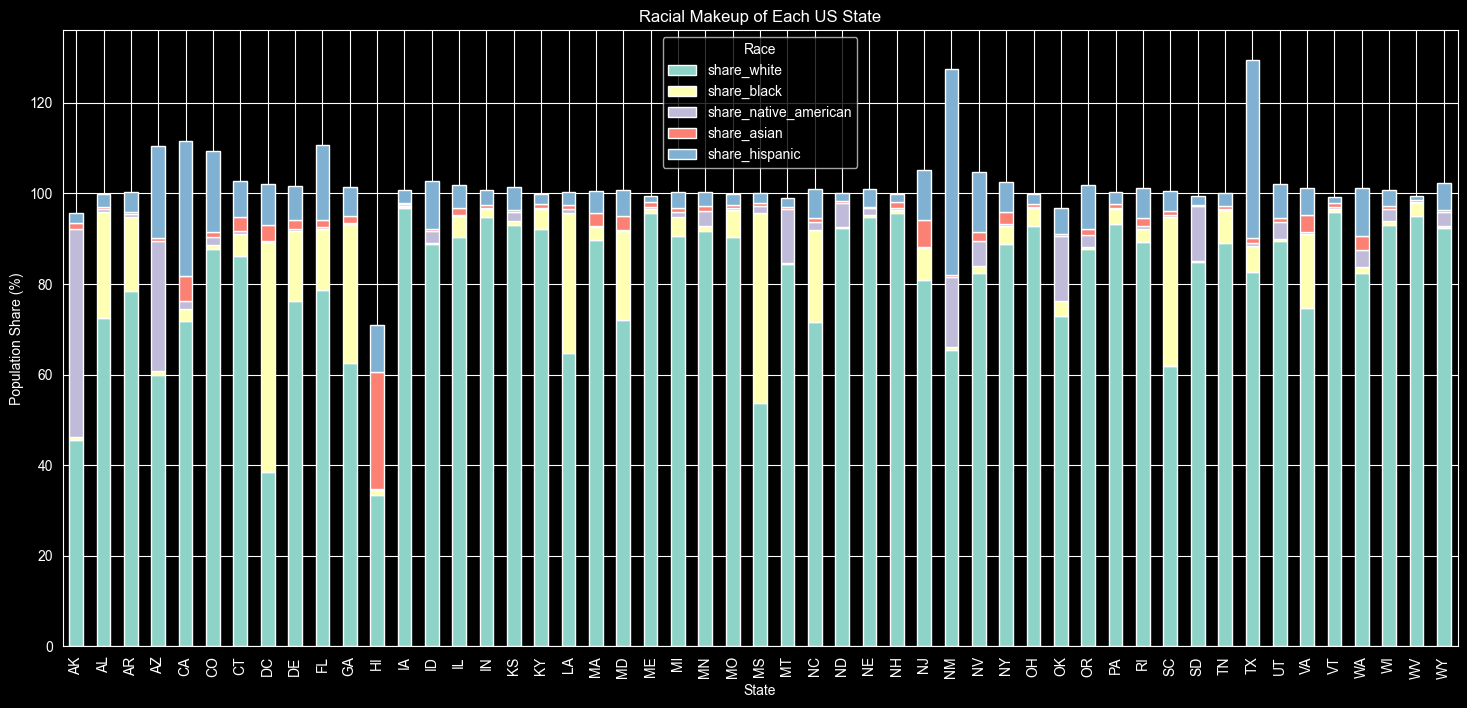

In [77]:
race_by_state.plot(
    kind="bar",
    stacked=True,
    figsize=(18, 8)
)

plt.title("Racial Makeup of Each US State")
plt.xlabel("State")
plt.ylabel("Population Share (%)")
plt.legend(title="Race")
plt.show()

# Create Donut Chart by of People Killed by Race

Hint: Use `.value_counts()`

In [78]:
race_counts = df_fatalities["race"].value_counts()

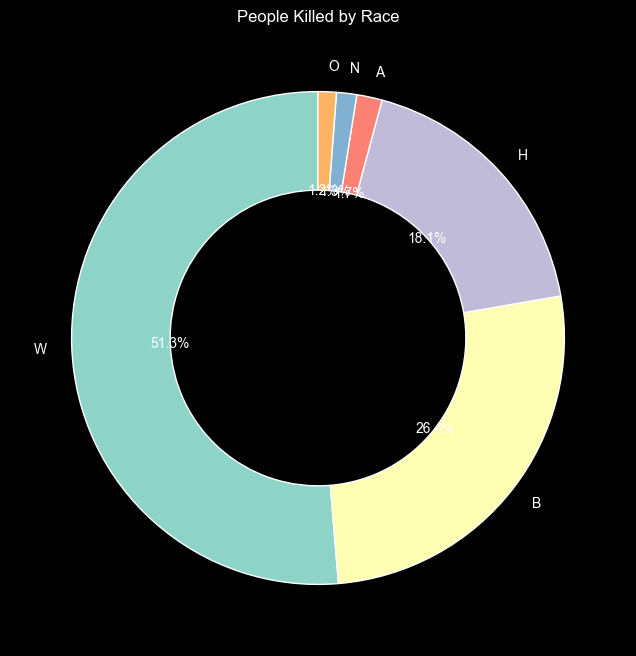

In [79]:
plt.figure(figsize=(8, 8))

plt.pie(
    race_counts.values,
    labels=race_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width": 0.4}
)

plt.title("People Killed by Race")
plt.show()

# Create a Chart Comparing the Total Number of Deaths of Men and Women

Use `df_fatalities` to illustrate how many more men are killed compared to women. 

In [82]:
gender_counts = df_fatalities["gender"].value_counts()
gender_counts.head()

gender
M    2428
F     107
Name: count, dtype: int64

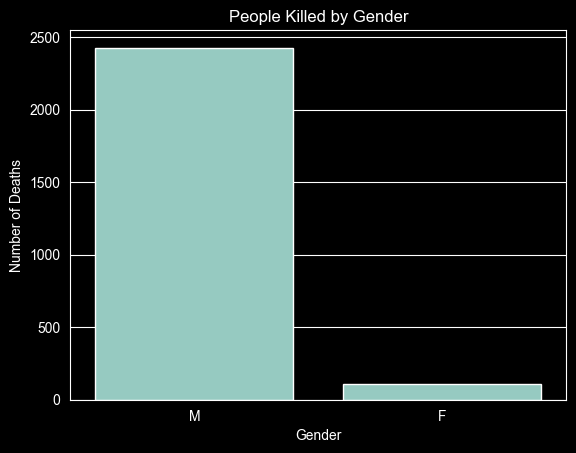

In [83]:
sns.barplot(
    x=gender_counts.index,
    y=gender_counts,
)

plt.title("People Killed by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Deaths")
plt.show()

# Create a Box Plot Showing the Age and Manner of Death

Break out the data by gender using `df_fatalities`. Is there a difference between men and women in the manner of death? 

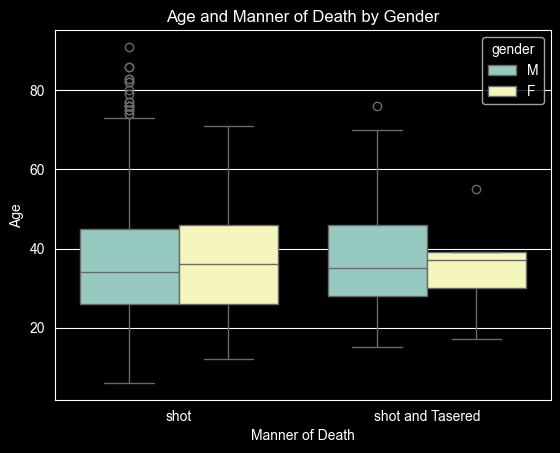

In [84]:
sns.boxplot(
    data=df_fatalities,
    x="manner_of_death",
    y="age",
    hue="gender"
)

plt.title("Age and Manner of Death by Gender")
plt.xlabel("Manner of Death")
plt.ylabel("Age")
plt.show()

# Were People Armed? 

In what percentage of police killings were people armed? Create chart that show what kind of weapon (if any) the deceased was carrying. How many of the people killed by police were armed with guns versus unarmed? 

In [93]:
armed_people = df_fatalities["armed"].value_counts().head(10)
armed_people

armed
gun               1398
knife              373
vehicle            177
unarmed            171
undetermined       117
toy weapon         104
machete             18
unknown weapon      18
Taser                9
ax                   9
Name: count, dtype: int64

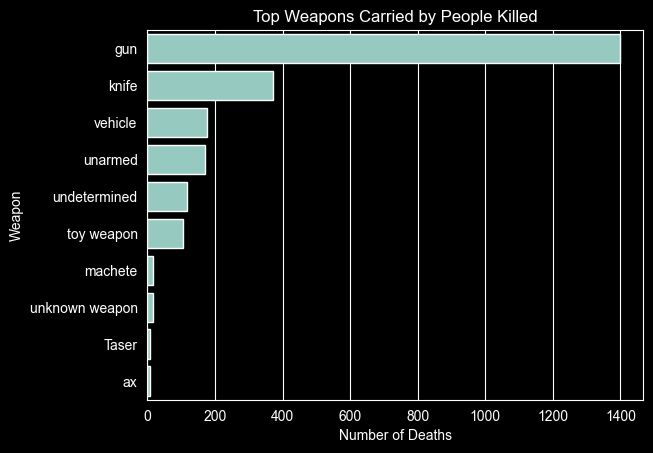

In [95]:
sns.barplot(
    x=armed_people.values,
    y=armed_people.index
)
plt.title("Top Weapons Carried by People Killed")
plt.xlabel("Number of Deaths")
plt.ylabel("Weapon")
plt.show()

In [97]:
unarmed_count = df_fatalities[df_fatalities["armed"] == "unarmed"].shape[0]
armed_count = df_fatalities[df_fatalities["armed"] != "unarmed"].shape[0]

print(f"Armed: {armed_count}")
print(f"Unarmed: {unarmed_count}")

Armed: 2364
Unarmed: 171


# How Old Were the People Killed?

Work out what percentage of people killed were under 25 years old.  

In [98]:
under_25 = df_fatalities[df_fatalities["age"] < 25].shape[0]
total = df_fatalities["age"].dropna().shape[0]

percentage_under_25 = (under_25 / total) * 100

print(f"{percentage_under_25:.2f}% of people killed were under 25 years old.")

18.31% of people killed were under 25 years old.


Create a histogram and KDE plot that shows the distribution of ages of the people killed by police. 

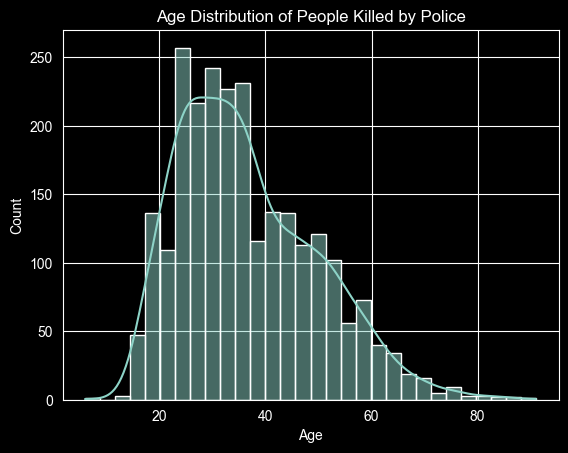

In [99]:
sns.histplot(
    data=df_fatalities,
    x="age",
    bins=30,
    kde=True
)

plt.title("Age Distribution of People Killed by Police")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

Create a seperate KDE plot for each race. Is there a difference between the distributions? 

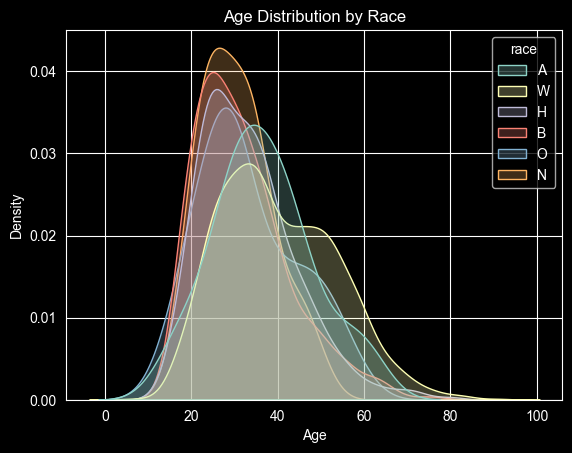

In [100]:
sns.kdeplot(
    data=df_fatalities.dropna(subset=["age", "race"]),
    x="age",
    hue="race",
    fill=True,
    common_norm=False
)

plt.title("Age Distribution by Race")
plt.xlabel("Age")
plt.show()

# Race of People Killed

Create a chart that shows the total number of people killed by race. 

In [101]:
race_counts = df_fatalities["race"].value_counts()


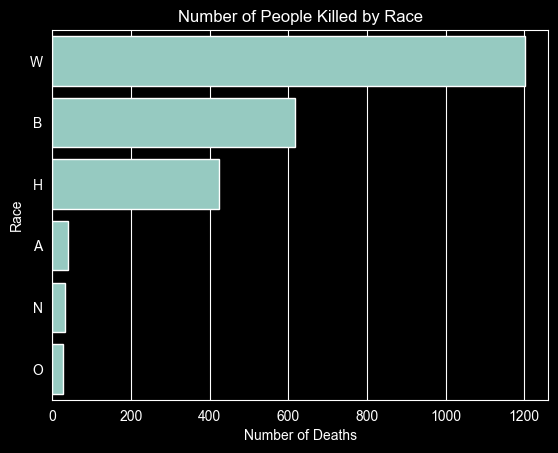

In [102]:
sns.barplot(
    x=race_counts.values,
    y=race_counts.index
)

plt.title("Number of People Killed by Race")
plt.xlabel("Number of Deaths")
plt.ylabel("Race")
plt.show()

# Mental Illness and Police Killings

What percentage of people killed by police have been diagnosed with a mental illness?

In [103]:
mental_counts = df_fatalities["signs_of_mental_illness"].value_counts()


In [104]:
mental_percentage = (
    mental_counts[True] / mental_counts.sum()
) * 100

print(f"{mental_percentage:.2f}% had signs of mental illness.")

24.97% had signs of mental illness.


# In Which Cities Do the Most Police Killings Take Place?

Create a chart ranking the top 10 cities with the most police killings. Which cities are the most dangerous?  

In [105]:
top_cities = df_fatalities["city"].value_counts().head(10)

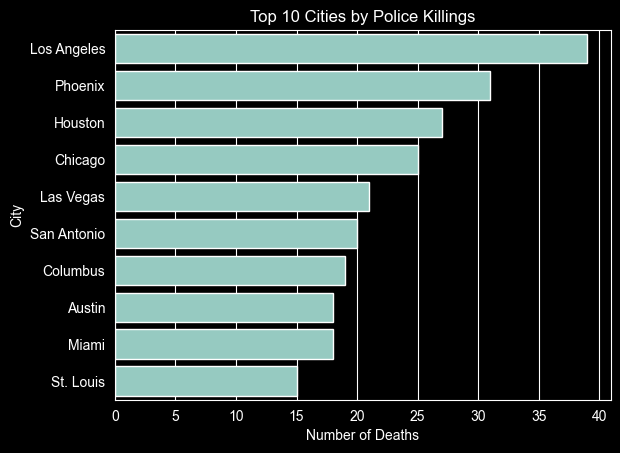

In [106]:
sns.barplot(
    x=top_cities.values,
    y=top_cities.index
)

plt.title("Top 10 Cities by Police Killings")
plt.xlabel("Number of Deaths")
plt.ylabel("City")
plt.show()

# Rate of Death by Race

Find the share of each race in the top 10 cities. Contrast this with the top 10 cities of police killings to work out the rate at which people are killed by race for each city. 

In [107]:
top_city_names = top_cities.index

top_city_data = df_fatalities[
    df_fatalities["city"].isin(top_city_names)
]


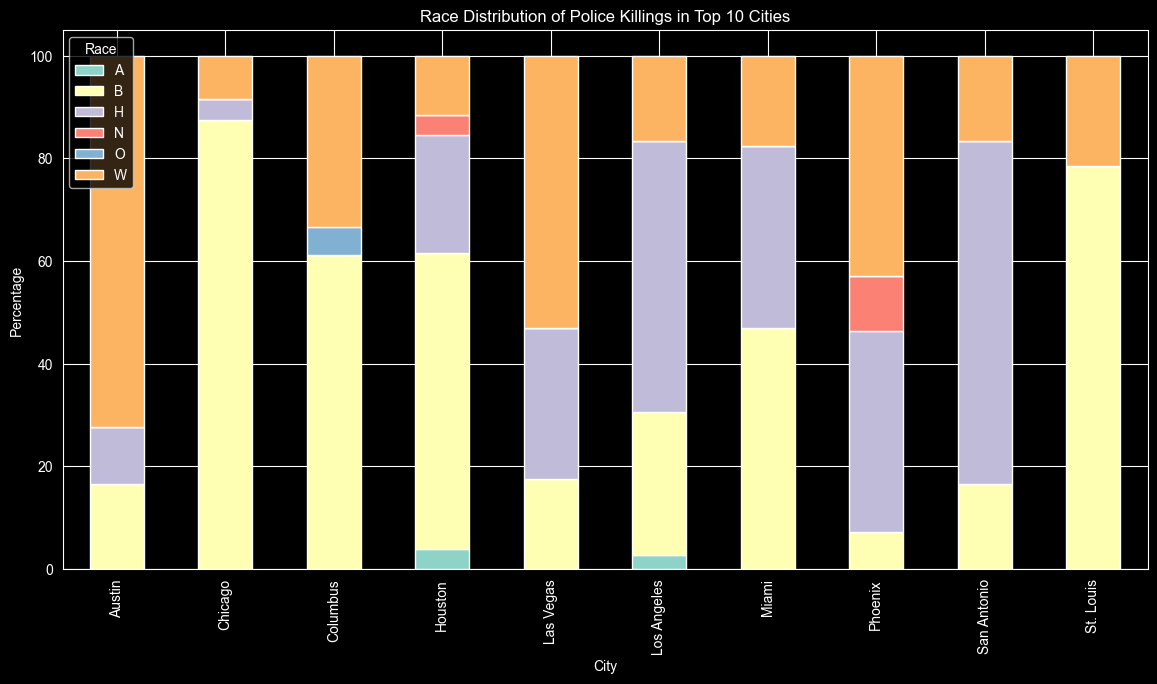

In [108]:
city_race_counts = pd.crosstab(
    top_city_data["city"],
    top_city_data["race"],
    normalize="index"
) * 100

city_race_counts.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 7)
)

plt.title("Race Distribution of Police Killings in Top 10 Cities")
plt.xlabel("City")
plt.ylabel("Percentage")
plt.legend(title="Race")
plt.show()

# Create a Choropleth Map of Police Killings by US State

Which states are the most dangerous? Compare your map with your previous chart. Are these the same states with high degrees of poverty? 

In [109]:
import plotly.express as px

state_counts = (
    df_fatalities["state"]
    .value_counts()
    .reset_index()
)

state_counts.columns = ["state", "deaths"]

In [110]:
fig = px.choropleth(
    state_counts,
    locations="state",
    locationmode="USA-states",
    color="deaths",
    scope="usa",
    color_continuous_scale="Reds",
    title="Police Killings by US State"
)
fig.show()


# Number of Police Killings Over Time

Analyse the Number of Police Killings over Time. Is there a trend in the data?

In [112]:
df_fatalities.head()

,id,name,date,manner_of_death,armed,age,gender,race,city,state,signs_of_mental_illness,threat_level,flee,body_camera
0,3,Tim Elliot,2015-02-01,shot,gun,53.00,M,A,Shelton,WA,True,attack,Not fleeing,False
1,4,Lewis Lee Lembke,2015-02-01,shot,gun,47.00,M,W,Aloha,OR,False,attack,Not fleeing,False
2,5,John Paul Quintero,2015-03-01,shot and Tasered,unarmed,23.00,M,H,Wichita,KS,False,other,Not fleeing,False
3,8,Matthew Hoffman,2015-04-01,shot,toy weapon,32.00,M,W,San Francisco,CA,True,attack,Not fleeing,False
4,9,Michael Rodriguez,2015-04-01,shot,nail gun,39.00,M,H,Evans,CO,False,attack,Not fleeing,False


In [113]:
df_fatalities["date"] = pd.to_datetime(df_fatalities["date"])

In [114]:
df_fatalities["date"] = pd.to_datetime(
    df_fatalities["date"],
    errors="coerce"
)

killings_over_time = (
    df_fatalities
    .dropna(subset=["date"])
    .groupby(df_fatalities["date"].dt.year)
    .size()
    .reset_index(name="deaths")
)

killings_over_time.columns = ["year", "deaths"]

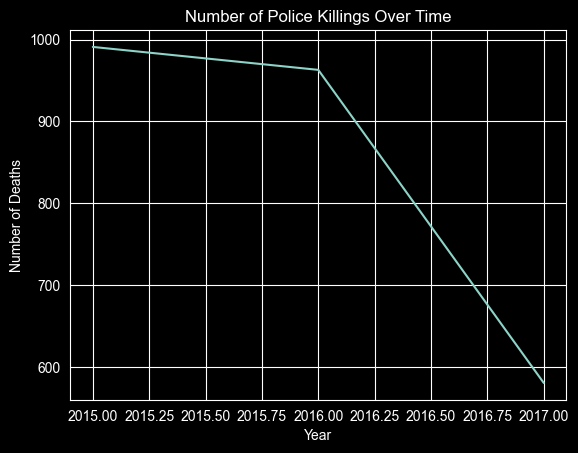

In [115]:
sns.lineplot(
    data=killings_over_time,
    x="year",
    y="deaths"
)

plt.title("Number of Police Killings Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Deaths")
plt.show()

# Epilogue

Now that you have analysed the data yourself, read [The Washington Post's analysis here](https://www.washingtonpost.com/graphics/investigations/police-shootings-database/).